# [LAB-02] 비지도 학습ㅣ07-DBSCAN 군집분석(실습코드).ipynb

# DBSCAN이란

**Density-Based Spatial Clustering of Applications with Noise**
이름 그대로 **밀도(빽빽한 정도)**를 기준으로 묶는 방법

> "데이터가 많이 모여 있는 곳을 그룹으로 보고, 혼자 떨어져 있는 데이터는 이상치로 뺀다"

- 빽빽하게 모인 구역 → 각각 하나의 군집
- 외따로 떨어진 점 → 노이즈

## 핵심 개념

| 값 | 의미 | 비유 |
|---|---|---|
| ε (epsilon) | 이웃으로 인정할 반경 | "반경 몇 m 안에 있으면 이웃으로 치자" |
| minPts | 그 안에 있어야 하는 최소 인원 | "몇 명 이상 있어야 '모여 있다'고 볼까" |

---

# 다른 군집 기법과의 비교

□ 군집 수를 미리 정하지 않아도 되고, 이상치를 따로 빼 준다

| 구분 | KMeans | 계층적 군집 | DBSCAN |
|---|---|---|---|
| 군집 기준 | 중심점(평균)까지의 거리 | 가까운 것끼리 순차 병합 | 주변이 얼마나 빽빽한가 |
| 군집 수 | 사전에 지정 (K 필요) | 덴드로그램에서 사후 결정 | **자동으로 결정됨** |
| 정해줘야 하는 값 | K | 연결 방식, 거리 척도 | ε(반경), minPts(최소 이웃 수) |
| 군집 모양 | 동그란 모양만 | 연결 방식에 따라 유연 | **길쭉하든 굽었든 자유** |
| 이상치 처리 | 억지로 어딘가에 넣음 | 별도 구분 없음 | **따로 빼준다 (Noise)** |
| 스케일링 | 필수 | 필수 | **필수 (더 중요)** |
| 주 용도 | 구조 요약, 세분화 | 계층 구조 파악, 소규모 데이터 | **이상치 탐지, 구조 탐색** |

---

# 활용 사례

□ 밀도가 곧 의미가 되는 문제에 쓴다

| 분야 | 활용 목적 |
|---|---|
| 상권 분석 | 사람이 몰리는 핫스팟 찾기 |
| 부동산 | 비정상 거래 분리 |
| 금융 | 이상 거래(사기) 탐지 |
| 제조 | 불량 패턴 탐색 |
| EDA | 본격 분석 전 이상치 걸러내기 |

---

# 장점과 단점

□ 예측·요약보다 이상치 탐지와 구조 탐색에 쓴다

| 👍 장점 | 👎 단점 |
|---|---|
| 군집 수를 미리 정할 필요 없음 | 핵심적인 하이퍼파라미터인 ε 을 정하기가 어렵다 |
| 이상치를 자동으로 분리해 준다 | 밀도 차이가 큰 데이터에는 잘 안 맞는다 |
| 모양이 자유로운 군집도 찾아낸다 | 변수 스케일에 매우 민감하다 |
| 실행할 때마다 결과가 거의 같다 | 군집의 "대표값(중심)"을 정의하기 어렵다 |

**실무 주의점**
- 스케일링 필수
- 변수가 많으면 거리의 의미가 흐려짐
- Noise는 오류가 아니다

---


## #01. 준비작업 
### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import * 

# 군집분석 관련 참조 
from sklearn.cluster import DBSCAN

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 불러오기 

In [2]:
origin = load_data("game_usage")
origin.head()

📚 게임 이용시간(time spent)과 레벨(game level)에 대한 가상 데이터


,time spent,game level
0,39,944
1,55,705
2,29,757
3,59,999
4,7,109


### 3. 데이터 스케일링 
DBSCAN은 "반경 epsilon 안에 몇 개가 있나"를 세는 알고리즘 \
변수마다 단위가 다르면 이 반경이 무슨 의미인지 알 수 없으므로 스케일링이 반드시 필요하다 

In [3]:
df1 = my_prep.scaling(origin, method="standard", verbose=False)
df1.head()

,time spent,game level
0,-0.251,1.475
1,0.326,0.607
2,-0.612,0.795
3,0.471,1.675
4,-1.405,-1.559


# DBSCAN 모델 적합

□ 주요 하이퍼파라미터

| 하이퍼파라미터 | 기본값 | 권장 |
|---|---|---|
| eps | 0.5 | 가장 중요. 표준화 기준 0.3 ~ 1.0 에서 탐색 시작 |
| min_samples | 5 | 5~10 (변수가 2~3개인 데이터의 경우 3~6 사이로 설정) |
| metric | 'euclidean' | 기본값 유지 |
| n_jobs | None | 사용할 CPU 코어 수 (-1은 전부 사용 → 빠르다) |

**핵심 판정 로직**
1. 반경 ε 의 원을 그린다
2. 그 안에 들어온 이웃의 개수를 센다
3. 이웃 수 ≥ minPts(5) → 이 점은 핵심(core)

- 🔴 기준 점
- ⚪ 원 안 이웃
- ⚪ 원 밖의 점

> 📌 random_state 가 없다. 랜덤하게 시작하지 않으므로 몇 번을 실행해도 결과가 같다

## #02. DBSCAN 군집 분석 
### 1. 기본 모델 적합 

In [4]:
# 모델 객체 생성 
estimator = DBSCAN(eps=0.5, min_samples=5, n_jobs=-1)

# 모델 학습 
estimator.fit(df1)

# DBSCAN에는 predict() 가 없다. 학습 결과는 labels_에 들어 있다. 
cluster = estimator.labels_
cluster

array([ 0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  1,  0, -1,  1,  0,
        1,  0,  0,  0,  0,  0,  0,  1,  0,  0,  1,  0,  0,  0,  0,  0,  1,
        0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0, -1, -1,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,
        0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  1,  0,  1,  0,  0,  0,  0,
        0,  0,  0,  1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0])

### 2. 군집수 / 노이즈 수 집계 

In [5]:
n_clusters = len(set(cluster)) - (1 if -1 in cluster else 0)
n_noise = (cluster == -1).sum()

print(f"군집 개수 : {n_clusters}개")
print(f"노이즈 개수: {n_noise}개 (전체의 {n_noise / len(cluster):.1%})")

군집 개수 : 2개
노이즈 개수: 5개 (전체의 5.0%)


### 3. 군집 결과를 포함하는 데이터프레임 구성 

In [6]:
df2 = df1.copy()
df2["cluster"] = cluster
df2.head()

,time spent,game level,cluster
0,-0.251,1.475,0
1,0.326,0.607,0
2,-0.612,0.795,0
3,0.471,1.675,0
4,-1.405,-1.559,1


## #03. 핵심 벡터(core) / 외곽 벡터(border) / 노이즈(noise) 구분 
### 핵심 벡터의 인덱스 
학습에 투입된 데이터프레임에서 이 위치에 해당하는 행 row이 핵심벡터로 구분된다 

In [7]:
estimator.core_sample_indices_

array([ 1,  2,  4,  5,  7,  8,  9, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21,
       22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
       40, 41, 42, 43, 44, 45, 46, 47, 48, 50, 51, 55, 57, 58, 60, 61, 62,
       63, 64, 65, 66, 68, 69, 70, 73, 75, 76, 77, 78, 79, 80, 81, 82, 83,
       84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 95, 96, 97, 98, 99])

### 2. 벡터 종류 구분

In [8]:
df3 = df2.copy()

# 기본적으로 모두 외곽 벡터로 지정 
df3["vector"] = "border"

# 핵심 벡터인 경우 'core'로 지정
df3.loc[estimator.core_sample_indices_, "vector"] = "core"

# 노이즈 분류 
df3.loc[df3["cluster"] == 1, "vector"] = "noise"

df3.head()

,time spent,game level,cluster,vector
0,-0.251,1.475,0,border
1,0.326,0.607,0,core
2,-0.612,0.795,0,core
3,0.471,1.675,0,border
4,-1.405,-1.559,1,noise


### 3. 군집별 시각화 

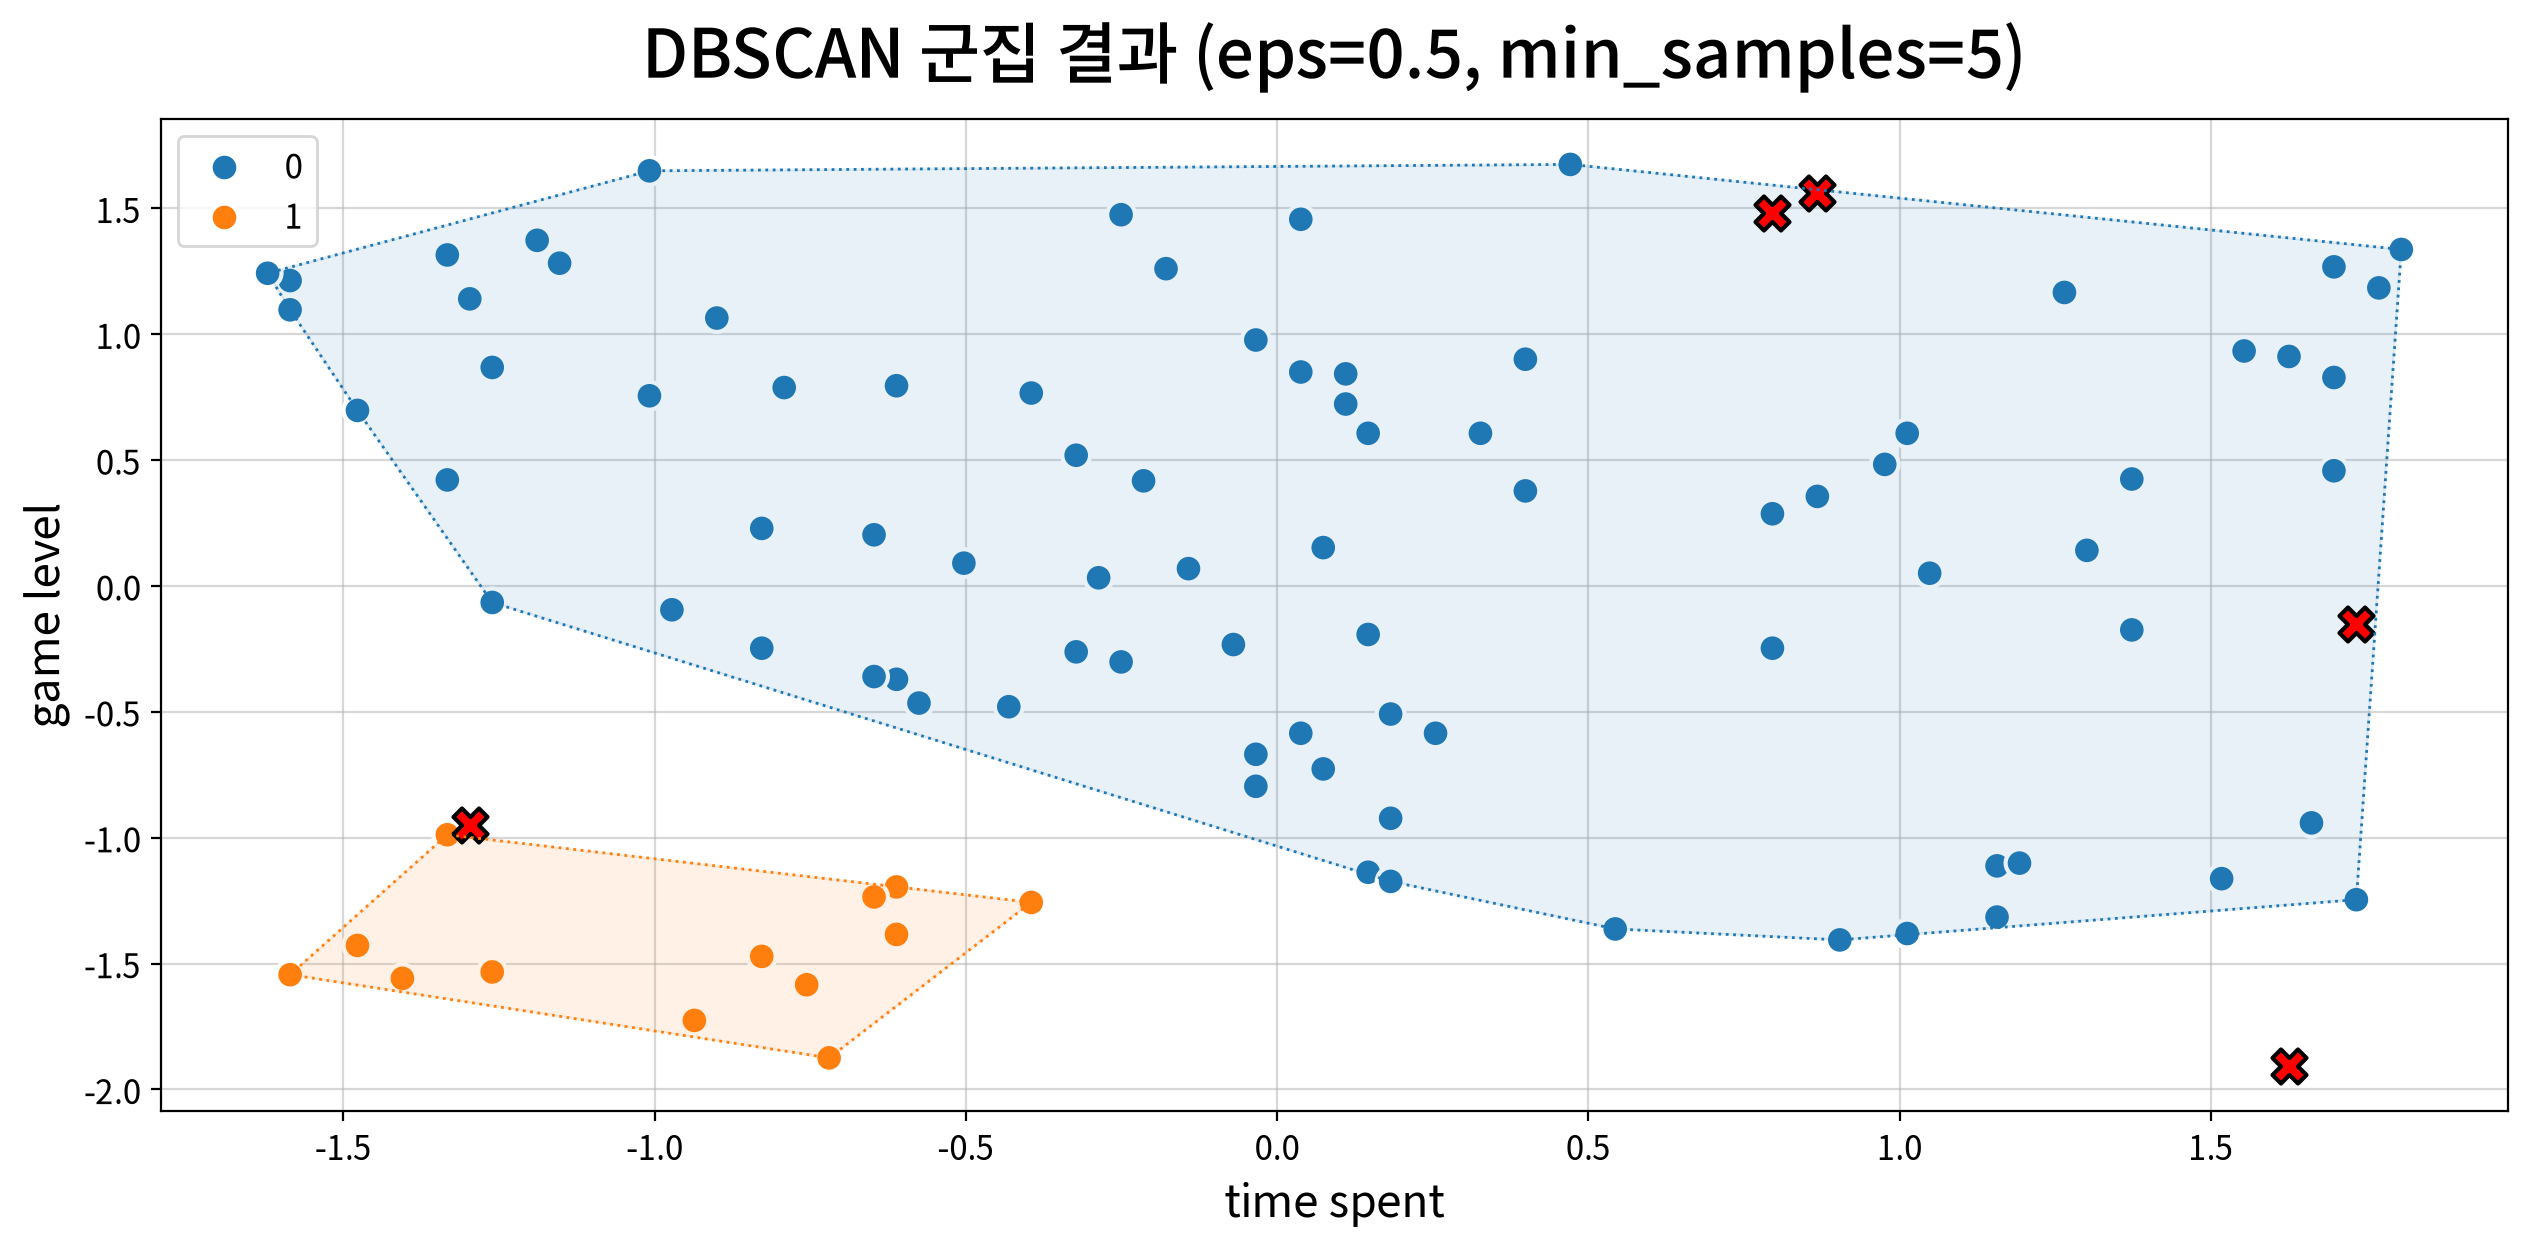

In [9]:
x_field = "time spent"
y_field = "game level"

normal = df3[df3["cluster"] != -1]  # 정상 군집
noise = df3[df3["cluster"] == -1]   # 노이즈

fig, ax = my_plot.init(title="DBSCAN 군집 결과 (eps=0.5, min_samples=5)",
                        xlabel=x_field, ylabel=y_field)

# 정상 군집 시각화
my_plot.scatterplot(data=normal, x=x_field, y=y_field, hue="cluster",
                     outline=True, ax=ax)

# 노이즈 시각화 --> X로 표시함
my_plot.scatterplot(data=noise, x=x_field, y=y_field,
                     color="red", edgecolor="black", marker="X",
                     size=150, outline=False, ax=ax)

my_plot.show()

### 3. 군집별 시각화 (결과 확인)

**DBSCAN 군집 결과 (eps=0.5, min_samples=5)**

**실행 조건과 결과**
- 데이터: game_usage / 100행 · 변수 2개 (time spent, game level)
- 설정: eps=0.5, min_samples=5
- **군집 개수: 2개**
- **노이즈: 5개 (5.0%)**

> 이 값들은 아무 근거 없이 정한 기본값이다.
>
> 나누고 싶었던 것보다 적게 나뉘었다 — 근거 없이 정한 기본값의 한계를 보여 주는 결과다.

그림에서 빨간 X 로 표시된 점이 노이즈다.

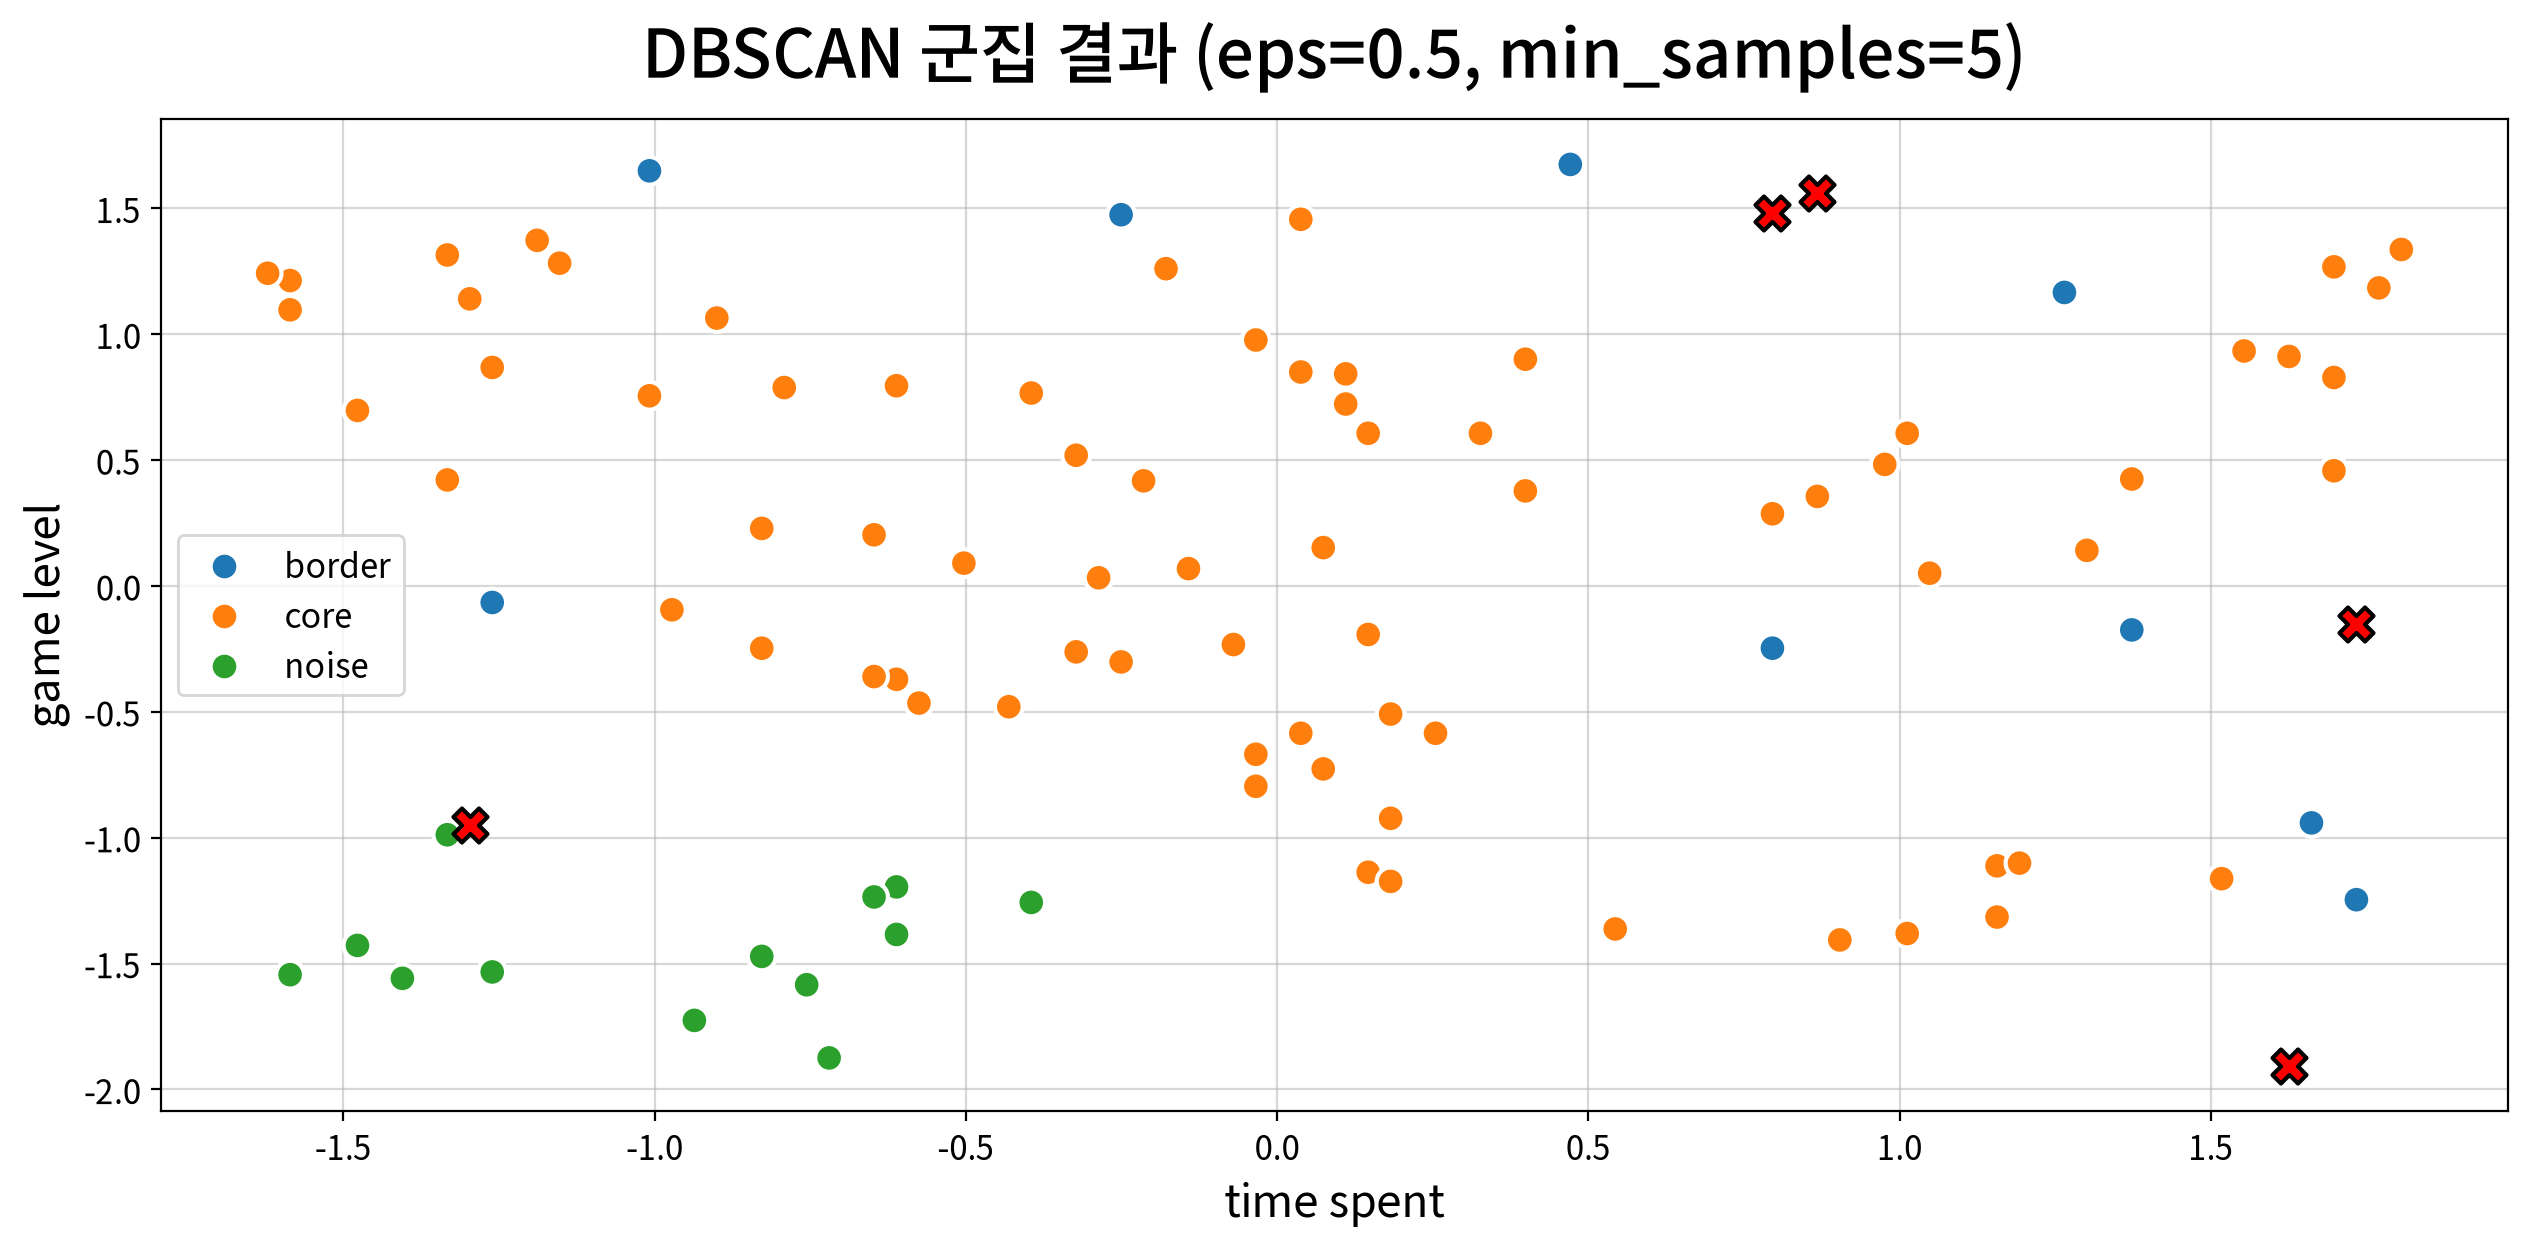

In [10]:
x_field = "time spent"
y_field = "game level"

normal = df3[df3["cluster"] != -1]  # 정상 군집
noise = df3[df3["cluster"] == -1]   # 노이즈

fig, ax = my_plot.init(title="DBSCAN 군집 결과 (eps=0.5, min_samples=5)",
                        xlabel=x_field, ylabel=y_field)

# 정상 군집 시각화
my_plot.scatterplot(data=normal, x=x_field, y=y_field, hue="vector",
                     outline=False, ax=ax)

# 노이즈 시각화 --> X로 표시함
my_plot.scatterplot(data=noise, x=x_field, y=y_field,
                     color="red", edgecolor="black", marker="X",
                     size=150, outline=False, ax=ax)

my_plot.show()

### 4. 벡터 유형(핵심 벡터 / 외곽 벡터 / 노이즈)별 시각화 (결과 확인)

**DBSCAN 군집 결과 (eps=0.5, min_samples=5)**

> **core**는 무리 한가운데, **border**는 가장자리, **noise**는 홀로 떨어진 점이다.
>
> 같은 데이터에서도 ε 과 minPts 값이 바뀌면 각 점의 소속은 달라진다.
>
> **앞 페이지에서 돌린 그 결과를, 이번에는 점의 유형별로 다시 칠한 것이다**

### 5. 두가지 형태의 시각화 결합 

In [11]:
# 벡터 유형에 따라 데이터를 세 덩어리로 나눈다 
core = df3[df3["vector"] == "core"] # 핵심 벡터 
border = df3[df3["vector"] == "border"] # 외곽 벡터
noise = df3[df3["vector"] == "noise"] # 노이즈 

display(core.head())
display(border.head())  
display(border.head())

,time spent,game level,cluster,vector
1,0.326,0.607,0,core
2,-0.612,0.795,0,core
5,-0.395,0.766,0,core
7,-0.575,-0.465,0,core
8,0.146,-1.137,0,core


,time spent,game level,cluster,vector
0,-0.251,1.475,0,border
3,0.471,1.675,0,border
6,-1.261,-0.066,0,border
10,-1.008,1.649,0,border
14,0.795,1.482,-1,border


,time spent,game level,cluster,vector
0,-0.251,1.475,0,border
3,0.471,1.675,0,border
6,-1.261,-0.066,0,border
10,-1.008,1.649,0,border
14,0.795,1.482,-1,border


### 5. 두 가지 형태의 시각화 결합(2) - 세 덩어리를 합쳐서 시각화 

TypeError: scatterplot() got an unexpected keyword argument 'label'

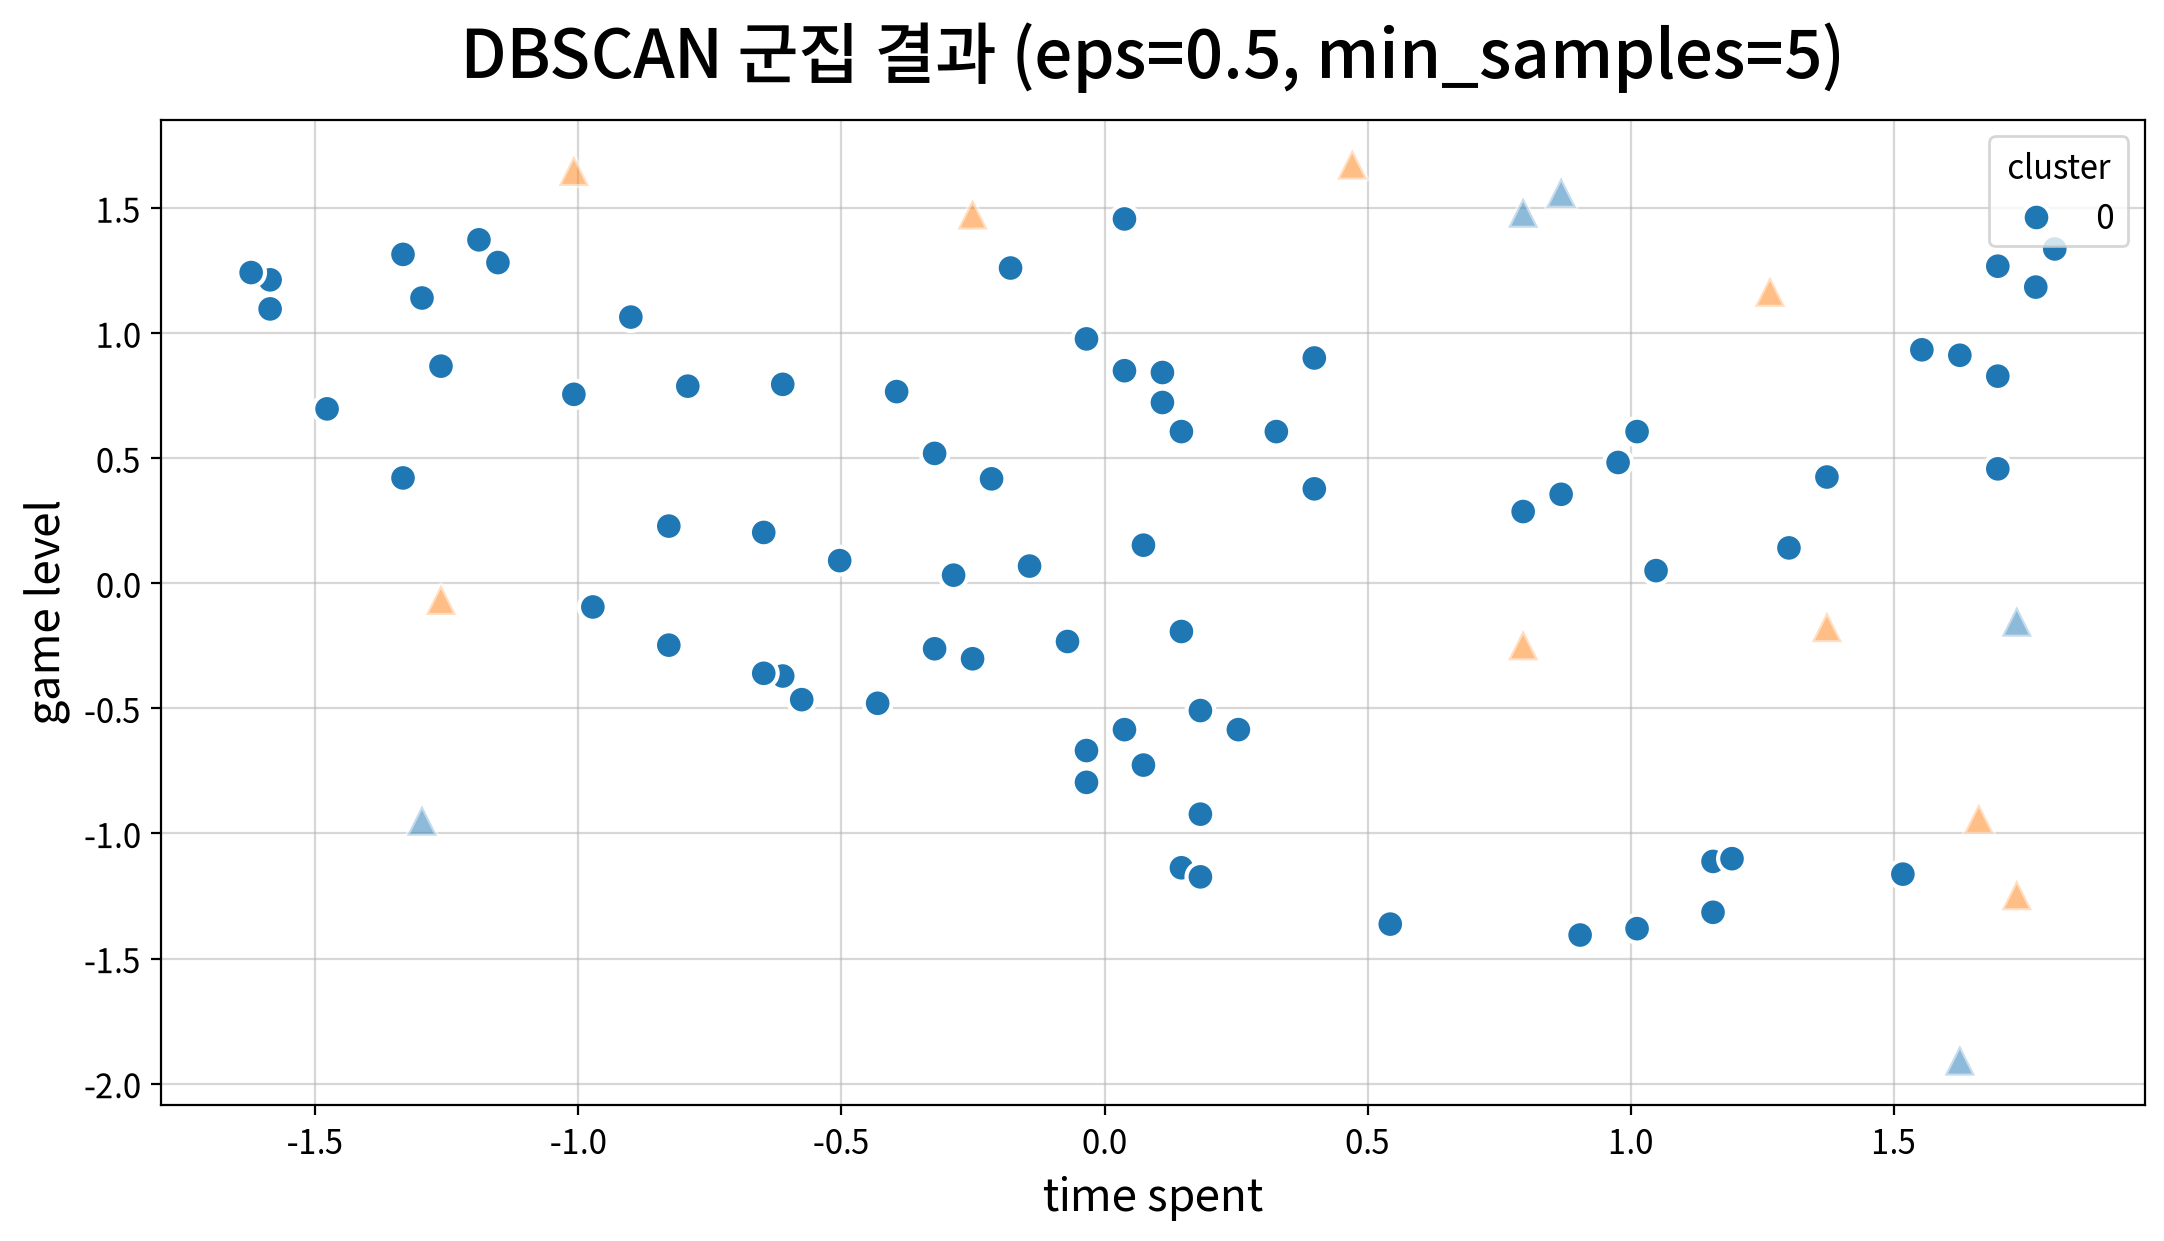

In [12]:
x_field = "time spent"
y_field = "game level"
palette = "tab10"  # 군집 색상 팔레트 (군집을 구분하는 모든 그래프에 동일 적용)

fig, ax = my_plot.init(title="DBSCAN 군집 결과 (eps=0.5, min_samples=5)",
                        xlabel=x_field, ylabel=y_field)

# 1) 핵심 벡터 --> 군집별 색상, 진한 동그라미
my_plot.scatterplot(data=core, x=x_field, y=y_field, hue="cluster",
                     palette=palette, marker="o", size=100,
                     outline=False, ax=ax)

# 2) 외곽 벡터 --> 군집별 색상(동일), 연한 세모 / 범례는 중복되므로 끈다
my_plot.scatterplot(data=border, x=x_field, y=y_field, hue="cluster",
                     palette=palette, marker="^", size=120, alpha=0.5,
                     outline=False, ax=ax, legend=False)

# 3) 노이즈 --> 군집이 없으므로 팔레트 없이 빨간 X 하나로 표시한다
my_plot.scatterplot(data=noise, x=x_field, y=y_field,
                     color="red", edgecolor="black", marker="X",
                     size=150, outline=False, ax=ax, label="noise")

# 4) 외곽선은 군집(cluster) 단위로 한 번에 그린다 (핵심 + 외곽 = 노이즈가 아닌 데이터)
my_plot.plot_hull(data=df3[df3["cluster"] != -1], x=x_field, y=y_field,
                   hue="cluster", palette=palette, ax=ax)

my_plot.show()

In [ ]:
import importlib
importlib.reload(my_plot)

<module 'helpers.my_plot' from 'C:\\py_temp\\15_LAB\\helpers\\my_plot.py'>